# Aperiodic analysis of sleep data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg 
import pickle
import statsmodels.api as sm
import statsmodels.formula.api as smf
import scipy.stats as stats
import yasa
import mne
from matplotlib.colors import Normalize, ListedColormap

In [2]:
# modified yasa plotting functions

def topoplot(
    data,
    montage="standard_1020",
    vmin=None,
    vmax=None,
    mask=None,
    title=None,
    cmap=None,
    n_colors=100,
    cbar_title=None,
    cbar_ticks=None,
    figsize=(6, 6),
    dpi=80,
    fontsize=14,
    axes=None,
    **kwargs,
):
    """
    Topoplot.

    This is a wrapper around :py:func:`mne.viz.plot_topomap`.

    For more details, please refer to this `example notebook
    <https://github.com/raphaelvallat/yasa/blob/master/notebooks/15_topoplot.ipynb>`_.

    .. versionadded:: 0.4.1

    Parameters
    ----------
    data : :py:class:`pandas.Series`
        A pandas Series with the values to plot. The index MUST be the channel
        names (e.g. ['C4', 'F4'] or ['C4-M1', 'C3-M2']).
    montage : str
        The name of the montage to use. Valid montages can be found at
        :py:func:`mne.channels.make_standard_montage`.
    vmin, vmax : float
        The minimum and maximum values of the colormap. If None, these will be
        defined based on the min / max values of ``data``.
    mask : :py:class:`pandas.Series`
        A pandas Series indicating the significant electrodes. The index MUST
        be the channel names (e.g. ['C4', 'F4'] or ['C4-M1', 'C3-M2']).
    title : str
        The plot title.
    cmap : str
        A matplotlib color palette. A list of color palette can be found at:
        https://seaborn.pydata.org/tutorial/color_palettes.html
    n_colors : int
        The number of colors to discretize the color palette.
    cbar_title : str
        The title of the colorbar.
    cbar_ticks : list
        The ticks of the colorbar.
    figsize : tuple
       Width, height in inches.
    dpi : int
        The resolution of the plot.
    fontsize : int
        Global font size of all the elements of the plot.
    **kwargs : dict
        Other arguments that are passed to :py:func:`mne.viz.plot_topomap`.

    Returns
    -------
    fig : :py:class:`matplotlib.figure.Figure`
        Matplotlib Figure

    Examples
    --------

    1. Plot all-positive values

    .. plot::

        >>> import yasa
        >>> import pandas as pd
        >>> data = pd.Series([4, 8, 7, 1, 2, 3, 5],
        ...                  index=['F4', 'F3', 'C4', 'C3', 'P3', 'P4', 'Oz'],
        ...                  name='Values')
        >>> fig = yasa.topoplot(data, title='My first topoplot')

    2. Plot correlation coefficients (values ranging from -1 to 1)

    .. plot::

        >>> import yasa
        >>> import pandas as pd
        >>> data = pd.Series([-0.5, -0.7, -0.3, 0.1, 0.15, 0.3, 0.55],
        ...                  index=['F3', 'Fz', 'F4', 'C3', 'Cz', 'C4', 'Pz'])
        >>> fig = yasa.topoplot(data, vmin=-1, vmax=1, n_colors=8,
        ...                     cbar_title="Pearson correlation")
    """
    # Increase font size while preserving original
    old_fontsize = plt.rcParams["font.size"]
    plt.rcParams.update({"font.size": fontsize})
    plt.rcParams.update({"savefig.bbox": "tight"})
    plt.rcParams.update({"savefig.transparent": "True"})

    # Make sure we don't do any in-place modification
    assert isinstance(data, pd.Series), "Data must be a Pandas Series"
    data = data.copy()

    # Add mask, if present
    if mask is not None:
        assert isinstance(mask, pd.Series), "mask must be a Pandas Series"
        assert mask.dtype.kind in "bi", "mask must be True/False or 0/1."
    else:
        mask = pd.Series(1, index=data.index, name="mask")

    # Convert to a dataframe (col1 = values, col2 = mask)
    data = data.to_frame().join(mask, how="left")

    # Preprocess channel names: C4-M1 --> C4
    data.index = data.index.str.split("-").str.get(0)

    # Define electrodes coordinates
    Info = mne.create_info(data.index.tolist(), sfreq=100, ch_types="eeg")
    Info.set_montage(montage, match_case=False, on_missing="ignore")
    chan = Info.ch_names

    # Define vmin and vmax
    if vmin is None:
        vmin = data.iloc[:, 0].min()
    if vmax is None:
        vmax = data.iloc[:, 0].max()

    # Choose and discretize colormap
    if cmap is None:
        if vmin < 0 and vmax <= 0:
            cmap = "mako"
        elif vmin < 0 and vmax > 0:
            cmap = "Spectral_r"
        elif vmin >= 0 and vmax > 0:
            cmap = "rocket_r"

    cmap = ListedColormap(sns.color_palette(cmap, n_colors).as_hex())

    if "sensors" not in kwargs:
        kwargs["sensors"] = True
    if "res" not in kwargs:
        kwargs["res"] = 256
    if "names" not in kwargs:
        kwargs["names"] = chan   
    if "mask_params" not in kwargs:
        kwargs["mask_params"] = dict(marker=None)

    # Hidden feature: if names='values', show the actual values.
    if kwargs["names"] == "values":
        kwargs["names"] = data.iloc[:, 0][chan].round(2).to_numpy()

    # Start the plot
    with sns.axes_style("white"):
        if axes is None:
            fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
        else:
            fig = plt.gcf()
            ax = axes
        # Plot topomap
        im, _ = mne.viz.plot_topomap(
            data=data.iloc[:, 0][chan],
            pos=Info,
            vlim=(vmin, vmax), 
            mask=data.iloc[:, 1][chan],
            cmap=cmap,
            show=False,
            axes=ax,
            **kwargs,
        )

        if title is not None:
            ax.set_title(title)

        # Add colorbar
        if cbar_title is None:
            cbar_title = data.iloc[:, 0].name

        cax = fig.add_axes([0.95, 0.3, 0.02, 0.5])
        cbar = fig.colorbar(im, cax=cax, ticks=cbar_ticks, fraction=0.5)
        cbar.set_label(cbar_title)

        # Revert font-size
        plt.rcParams.update({"font.size": old_fontsize})
        
    return fig

In [58]:
# load dataframe and psds
df = pd.read_csv('/media/administrator/data/Study_1_data/Statistics/aperiodic_sleep.csv').groupby(['Subject','Condition','Stage','Chan']).mean()
psds = pickle.load(open('/media/administrator/data/Study_1_data/Statistics/fooof_groups_dict.pkl', 'rb'))
couple = pd.read_csv('/media/administrator/data/Study_1_data/Statistics/SW_spindle_summary/sws_full.csv', index_col=0)

In [59]:
good_subs = ['0RCB4IRJ', '3LFLTILW', '6QJ3ITMT', '7XVWEVOK', 'A4VCLD2I', 
             'CWESJCNJ', 'D1BOI2AY', 'FUOPOVNF', 'HTXEYPW6', 'IYPJJ2KE', 
             'KEQB5AWM', 'RVQL2MRD', 'UDLD86TO', 'W6AX3IMN', 'Y9VJUA9F', 
             'YIOYSRPX', 'EQDORXF6']
df = df.loc[good_subs]
couple = couple.loc[couple['Subject'].isin(good_subs)]
couple = couple[couple['Stage'] == 3]
couple = couple.groupby(['Channel','Condition','Subject']).mean().reset_index()

In [79]:
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.decomposition import PCA
from openTSNE import TSNE

# extract and standardize aperiodic features
scaler = StandardScaler()
X = scaler.fit_transform(pd.DataFrame(df[['Slope','Intercept']]))
y = df.reset_index().Stage.values

# apply PCA
pca_aperiodic = PCA(n_components=2).fit_transform(X)

# apply tSNE to pca applied to aperiodic features
tsne_pca = TSNE(perplexity=30, metric="euclidean").fit(pca_aperiodic).transform(pca_aperiodic)

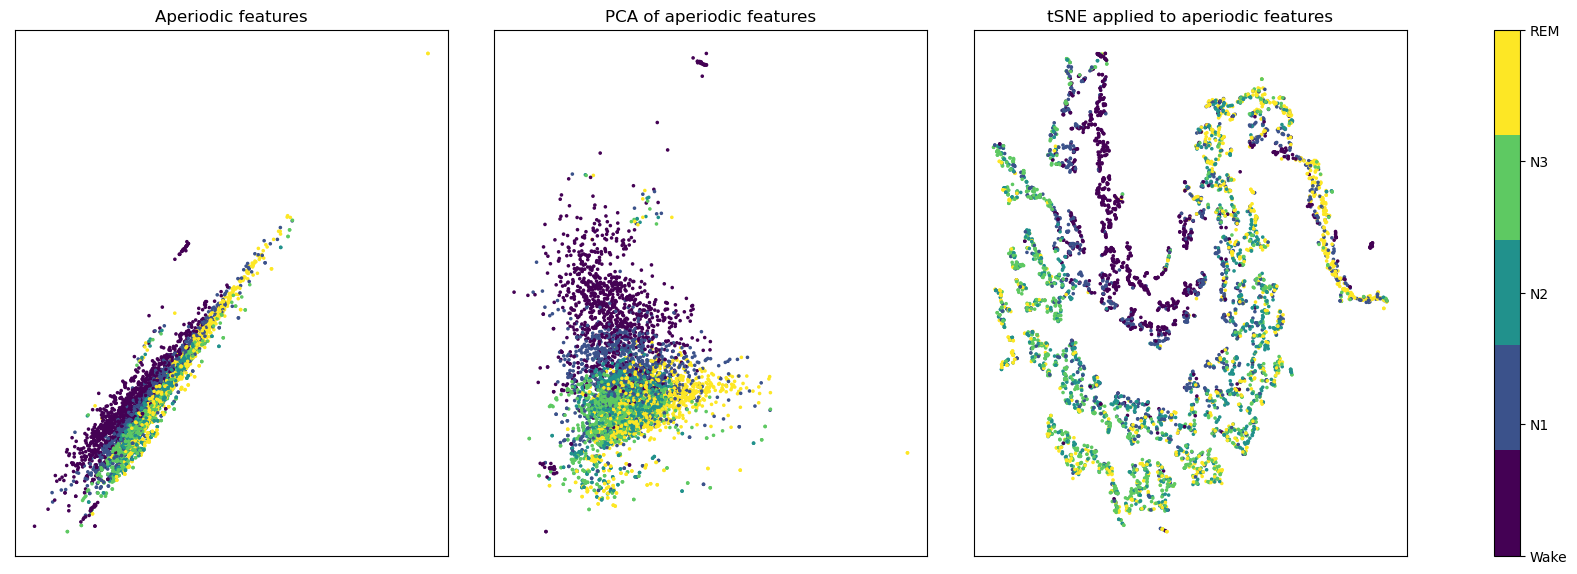

In [80]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

# plot raw, PCA, and tSNE applied to aperiodic features
fig, ax = plt.subplots(1, 3, figsize=(18,6))
ax[0].scatter(X[:,0], X[:,1], s=2.5, c=y)
ax[0].set_title('Aperiodic features')
ax[1].scatter(pca_aperiodic[:,0], pca_aperiodic[:,1], s=2.5, c=y)
ax[1].set_title('PCA of aperiodic features')
ax[2].scatter(tsne_pca[:,0], tsne_pca[:,1], s=2.5, c=y)
ax[2].set_title('tSNE applied to aperiodic features')

plt.tight_layout()

# add discrete color bar
norm = Normalize(vmin=y.min(), vmax=y.max())
cmap = plt.cm.get_cmap('viridis', int(y.max()-y.min()+1))
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax.ravel().tolist(), ticks=np.arange(y.min(), y.max()+1))
cbar.ax.set_yticklabels(['Wake','N1','N2','N3','REM'])

# remove x and y ticks
for i in range(3):
    ax[i].set_xticks([])
    ax[i].set_yticks([])

In [22]:
# load behavioral data
df_slalom = pd.read_csv('/media/administrator/data/Study_1_data/Statistics/Slalom/Slalom_results.csv', index_col=0)
for i in zip(['9PJZ8Z8F','475MQ9BL','5LNKD1MG','CWESJCNJ','6QF3HOJC','IBYYXKMB','NW2JV7YA']): #'RVQL2MRD'
    df_slalom.drop(df_slalom.loc[df_slalom['Subject']==i[0]].index, inplace=True)
df_slalom = df_slalom[df_slalom.Subject.isin(good_subs)]
df_slalom = df_slalom.set_index(['Subject','Condition','Night','Block'])

In [23]:
# find % of subject, condition, channel slopes that are negative
df_neg = df.loc[df['Slope'] < 0].reset_index()
df_neg = df_neg[['Subject','Condition','Chan','Stage','Slope','R^2']]
df_neg = df_neg.set_index(['Subject','Condition','Chan', 'Stage'])
df_neg

Slope       R^2
Subject  Condition Chan Stage                    
0RCB4IRJ down      T7   0.0   -0.505230  0.761205
                   T8   0.0   -0.099562  0.454214
         sham      F7   0.0   -0.152941  0.593691
                   F8   0.0   -0.367150  0.681392
                   Fp1  0.0   -0.008957  0.669208
                   Fp2  0.0   -0.151085  0.467973
                   Fpz  0.0   -0.056253  0.946373
                   T7   0.0   -0.049005  0.836052
         up        T7   0.0   -0.762036  0.819254
3LFLTILW down      T7   0.0   -0.009362  0.527467
         sham      T7   1.0   -0.428993  0.740326
         up        F8   0.0   -0.110245  0.716918
                   T8   0.0   -0.111437  0.161676
A4VCLD2I down      F7   0.0   -0.140860  0.510896
FUOPOVNF sham      T7   0.0   -0.014425  0.725641
IYPJJ2KE up        T7   0.0   -0.238769  0.626033
                        1.0   -0.170614  0.449961
KEQB5AWM down      F7   1.0   -0.253864  0.286883
         up        C3   1.0   -0.062818  0.655522
                   F7   1.0   -0.019877  0.796214
                   T7   1.0   -0.418211  0.702004
RVQL2MRD down      M1   3.0   -0.138323  0.800212
                   M2   3.0   -0.138323  0.800212
         up        M1   0.0   -0.183460  0.586206
                   M2   0.0   -0.183460  0.586206
                   T7   0.0   -0.282734  0.595061
UDLD86TO down      T8   0.0   -0.109345  0.422869
W6AX3IMN up        M1   0.0   -0.034809  0.520895
                   M2   0.0   -0.034809  0.520895
Y9VJUA9F down      T7   0.0   -0.175484  0.586594
         sham      T7   0.0   -0.379193  0.604770
                   T8   0.0   -0.205107  0.229273
YIOYSRPX down      F8   0.0   -0.027376  0.573729
                   T7   0.0   -0.021519  0.110896
EQDORXF6 down      T7   0.0   -0.339480  0.851147

In [22]:
# Step 1: Total number of observations
total_observations = len(df)
print(total_observations)

# Step 2: Number of negative slopes
negative_slopes_count = len(df_neg)
print(negative_slopes_count)

# Step 3: Calculating the percentage
percentage_negative_slopes = (negative_slopes_count / total_observations) * 100
percentage_negative_slopes

5750
5750


100.0

In [34]:
# Merge the two dataframes on 'Subject' and 'Condition'
merged_df = pd.merge(df, df_slalom, on=['Subject', 'Condition'], how='inner').reset_index()
#merged_df = pd.merge(merged_df, couple, on=['Subject', 'Condition'], how='inner').reset_index()

In [60]:
# rename column Channel to Chan
couple = couple.rename(columns={'Channel':'Chan'})

In [35]:
# Group df_aperiodic_sleep by 'Subject', 'Condition', and 'Stage' to get average Slope for each sleep stage
avg_slope = df.groupby(['Subject', 'Condition', 'Chan', 'Stage'])[['Slope','Intercept']].mean().reset_index()

# Group df_slalom_results by 'Subject' and 'Condition' to get average contrast across all blocks
avg_contrast = df_slalom.groupby(['Subject', 'Condition'])['RMSE_difference_ratio'].mean().reset_index()

# Merge the two grouped dataframes
merged_avg = pd.merge(avg_slope, avg_contrast, on=['Subject', 'Condition'], how='inner')

# code stage as strings (0->W, 1->N1, 2->N2, 3->N3, 4->REM)
merged_avg['Stage'] = merged_avg['Stage'].replace({0.0:'W', 1.0:'NREM1', 2.0:'NREM2', 3.0:'NREM3', 4.0:'REM'})
merged_avg

,Subject,Condition,Chan,Stage,Slope,Intercept,RMSE_difference_ratio
0,0RCB4IRJ,down,C3,W,1.090349,0.934494,-4.508172
1,0RCB4IRJ,down,C3,NREM1,1.757489,1.393728,-4.508172
2,0RCB4IRJ,down,C3,NREM2,1.899201,1.558809,-4.508172
3,0RCB4IRJ,down,C3,NREM3,1.747444,1.259025,-4.508172
4,0RCB4IRJ,down,C3,REM,2.028939,1.799949,-4.508172
...,...,...,...,...,...,...,...
5400,YIOYSRPX,up,T8,W,0.181825,-0.193837,-5.705083
5401,YIOYSRPX,up,T8,NREM1,0.284777,-0.586536,-5.705083
5402,YIOYSRPX,up,T8,NREM2,0.661312,-0.336711,-5.705083
5403,YIOYSRPX,up,T8,NREM3,0.450147,-0.775033,-5.705083


In [61]:
merged_avg2 = pd.merge(merged_avg, couple, on=['Subject', 'Condition','Chan'], how='inner')
merged_avg2

,Subject,Condition,Chan,Stage_x,Slope_x,Intercept,RMSE_difference_ratio,Start,NegPeak,MidCrossing,...,Slope_y,Frequency,SigmaPeak,PhaseAtSigmaPeak,ndPAC,Stage_y,IdxChannel,CooccurringSpindle,CooccurringSpindlePeak,DistanceSpindleToSW
0,0RCB4IRJ,down,C3,W,1.090349,0.934494,-4.508172,3530.392488,3530.694765,3530.977087,...,534.033749,0.899494,3530.652070,-0.836539,0.253768,3.0,9.0,0.385772,3820.773336,0.018243
1,0RCB4IRJ,down,C3,NREM1,1.757489,1.393728,-4.508172,3530.392488,3530.694765,3530.977087,...,534.033749,0.899494,3530.652070,-0.836539,0.253768,3.0,9.0,0.385772,3820.773336,0.018243
2,0RCB4IRJ,down,C3,NREM2,1.899201,1.558809,-4.508172,3530.392488,3530.694765,3530.977087,...,534.033749,0.899494,3530.652070,-0.836539,0.253768,3.0,9.0,0.385772,3820.773336,0.018243
3,0RCB4IRJ,down,C3,NREM3,1.747444,1.259025,-4.508172,3530.392488,3530.694765,3530.977087,...,534.033749,0.899494,3530.652070,-0.836539,0.253768,3.0,9.0,0.385772,3820.773336,0.018243
4,0RCB4IRJ,down,C3,REM,2.028939,1.799949,-4.508172,3530.392488,3530.694765,3530.977087,...,534.033749,0.899494,3530.652070,-0.836539,0.253768,3.0,9.0,0.385772,3820.773336,0.018243
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5090,YIOYSRPX,up,T8,W,0.181825,-0.193837,-5.705083,9159.393939,9159.751302,9160.073035,...,310.664877,0.796188,9159.724432,-0.348575,0.200160,3.0,12.0,0.136364,5330.905382,-0.255208
5091,YIOYSRPX,up,T8,NREM1,0.284777,-0.586536,-5.705083,9159.393939,9159.751302,9160.073035,...,310.664877,0.796188,9159.724432,-0.348575,0.200160,3.0,12.0,0.136364,5330.905382,-0.255208
5092,YIOYSRPX,up,T8,NREM2,0.661312,-0.336711,-5.705083,9159.393939,9159.751302,9160.073035,...,310.664877,0.796188,9159.724432,-0.348575,0.200160,3.0,12.0,0.136364,5330.905382,-0.255208
5093,YIOYSRPX,up,T8,NREM3,0.450147,-0.775033,-5.705083,9159.393939,9159.751302,9160.073035,...,310.664877,0.796188,9159.724432,-0.348575,0.200160,3.0,12.0,0.136364,5330.905382,-0.255208


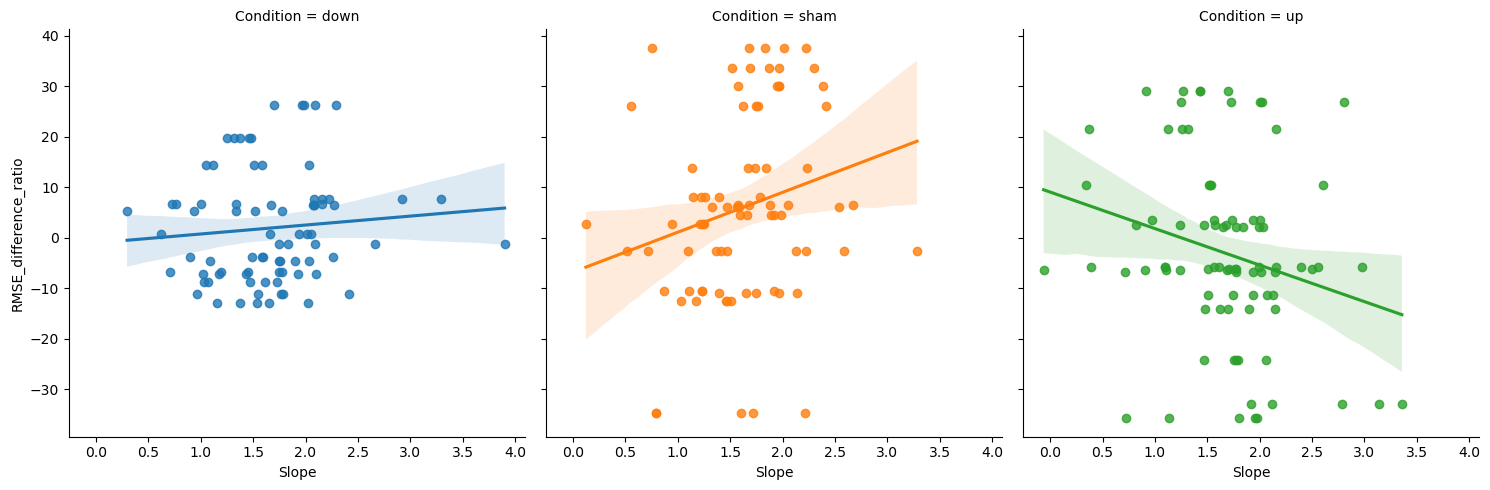

In [86]:
sns.lmplot(data=merged_avg[merged_avg.Chan=='C3'], x='Slope', y='RMSE_difference_ratio', 
           hue='Condition', col='Condition')

<AxesSubplot:xlabel='Stage', ylabel='Slope'>

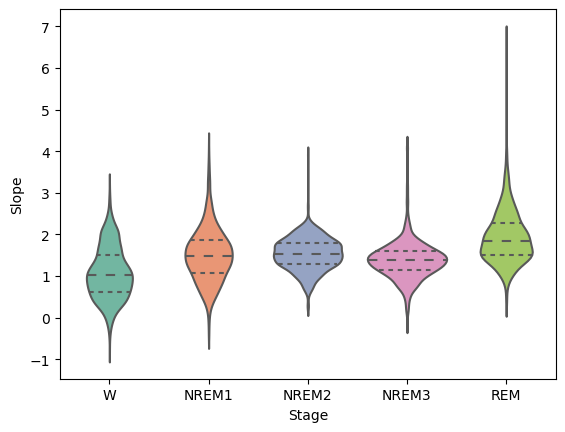

In [87]:
sns.violinplot(data=merged_avg, x='Stage', y='Slope', #hue='Condition', 
               inner='quartile', palette='Set2')

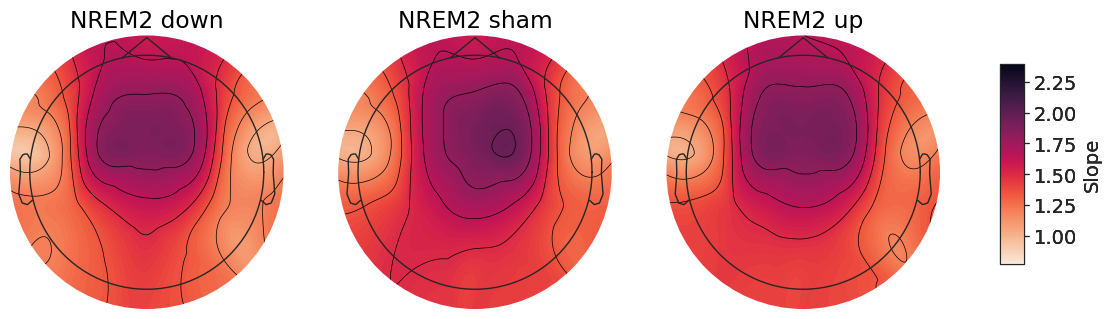

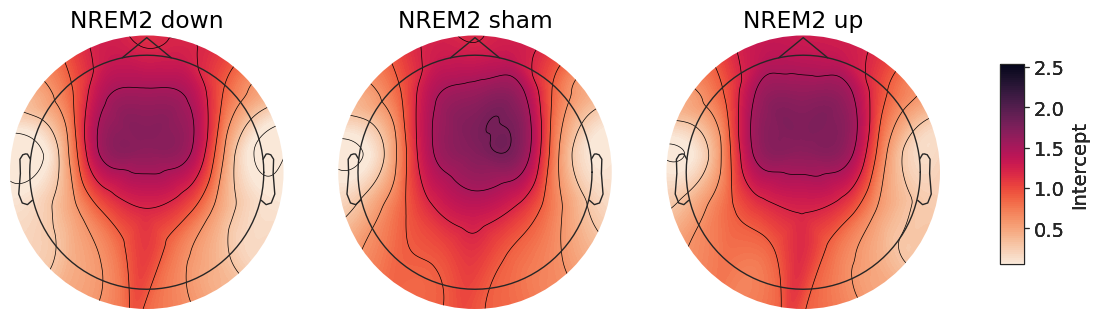

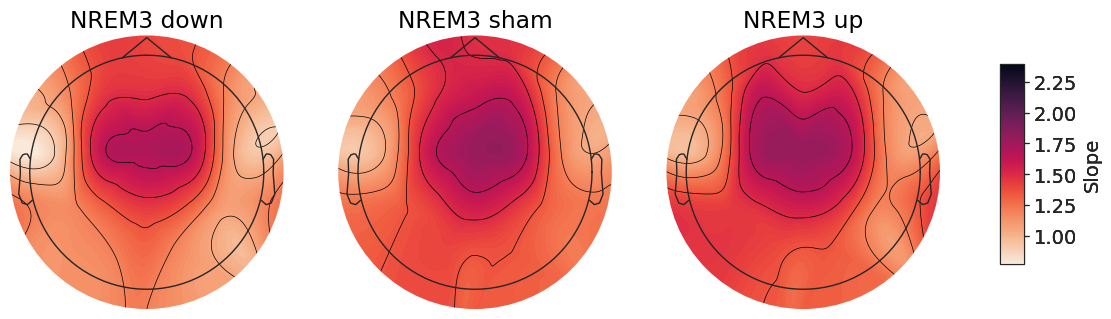

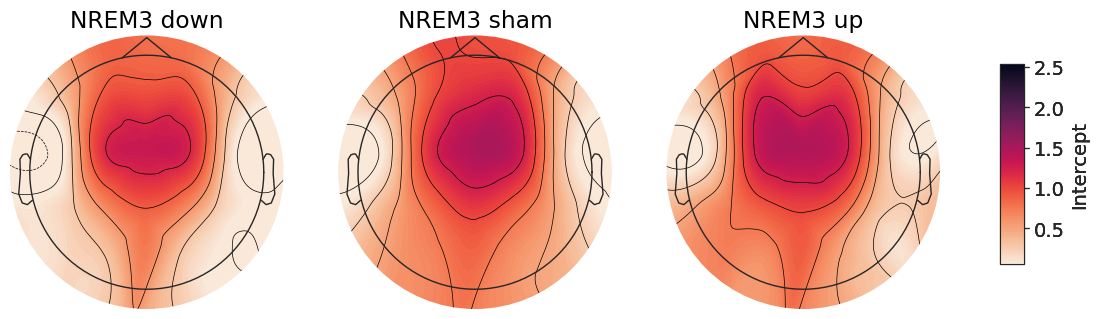

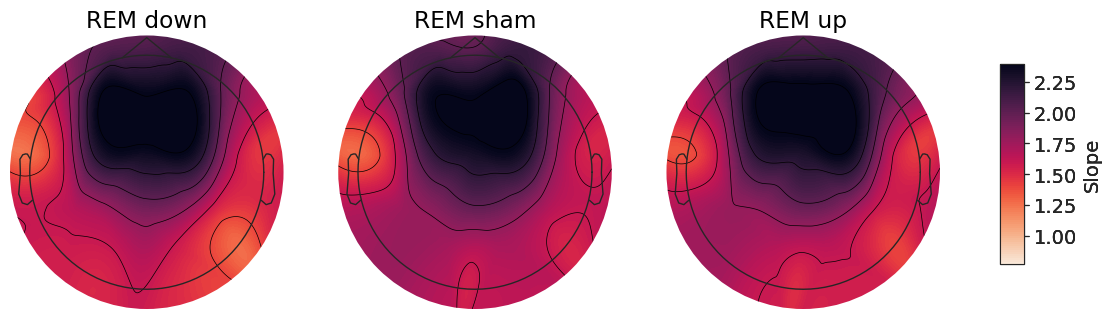

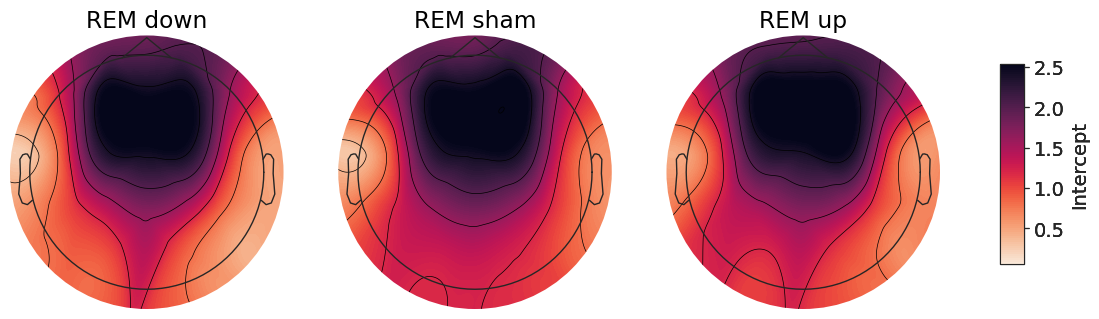

In [25]:
for stage in ['NREM2','NREM3','REM']: 
    # extract data for each parameter (slope & intercept)
    for param in ['Slope', 'Intercept']:
        # initialize figure
        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        # extract data for each stage and condition
        for cond, ax in zip(merged_avg.Condition.unique(), axes):
            # extract data for each stage and condition
            color_data =  merged_avg.groupby(['Stage','Condition','Chan'])[param].mean()#.loc[stage]
            data_ = merged_avg.groupby(['Stage','Condition','Chan'])[param].mean().loc[stage].loc[cond]
            vlim =(np.percentile(color_data, 2.5), np.percentile(color_data, 99))
            topoplot(data=data_,
                    vmin=vlim[0], vmax=vlim[1], 
                    montage="standard_1005", #cmap='viridis', 
                    title=f'{stage} {cond}', figsize=(4, 4), cbar_title=f'{param}', axes=ax,
                    **dict(names=None), # type: ignore
                    )

        # save figure    
        plt.savefig(f'/media/administrator/data/Study_1_data/Figures/Aperiodic/{stage}_{cond}_{param}.png') # type: ignore  

In [62]:
#data = merged_avg.groupby(['Condition','Stage','Chan','Subject'])[['Slope','Intercept','RMSE_difference_ratio']].mean()
data = merged_avg2.groupby(['Condition','Chan','Subject'])[['CooccurringSpindle','RMSE_difference_ratio']].mean()
data

CooccurringSpindle  RMSE_difference_ratio
Condition Chan Subject                                            
down      C3   0RCB4IRJ            0.385772              -4.508172
               3LFLTILW            0.388889             -11.056900
               6QJ3ITMT            0.337818              19.745673
               7XVWEVOK            0.316271               6.400106
               A4VCLD2I            0.218225               0.689669
...                                     ...                    ...
up        T8   RVQL2MRD            0.198718              21.500312
               UDLD86TO            0.273504             -24.183045
               W6AX3IMN            0.200000              10.443192
               Y9VJUA9F            0.378641             -11.355237
               YIOYSRPX            0.136364              -5.705083

[1019 rows x 2 columns]

In [64]:
# Define a function to compute correlations
def compute_correlations_cospindle(group):
    from scipy.stats import pearsonr
    corr_slope_sp, p_value_sp = pearsonr(group['CooccurringSpindle'], group['RMSE_difference_ratio'])
    
    return pd.Series({'Corr': corr_slope_sp, 'P_Value': p_value_sp})


# Group the data by Subject, Condition, Stage, and Chan
grouped_data = data.groupby(['Condition', 'Chan']).apply(compute_correlations_cospindle).reset_index()
print(grouped_data)

   Condition Chan      Corr   P_Value
0       down   C3 -0.162849  0.546775
1       down   C4  0.252613  0.345211
2       down   Cz -0.007713  0.977383
3       down   F3 -0.138943  0.607819
4       down   F4  0.175585  0.515400
..       ...  ...       ...       ...
64        up   P7 -0.023173  0.932114
65        up   P8  0.222221  0.408124
66        up   Pz  0.189257  0.482676
67        up   T7 -0.203565  0.449541
68        up   T8  0.158532  0.557595

[69 rows x 4 columns]


In [79]:
grouped_data

,Condition,Chan,Corr,P_Value
0,down,C3,-0.162849,0.546775
1,down,C4,0.252613,0.345211
2,down,Cz,-0.007713,0.977383
3,down,F3,-0.138943,0.607819
4,down,F4,0.175585,0.515400
...,...,...,...,...
64,up,P7,-0.023173,0.932114
65,up,P8,0.222221,0.408124
66,up,Pz,0.189257,0.482676
67,up,T7,-0.203565,0.449541


In [60]:
# Define a function to compute correlations
def compute_correlations_old(group):
    corr_slope_rmse = np.corrcoef(group['Slope'], group['RMSE_difference_ratio'])[0, 1]
    corr_intercept_rmse = np.corrcoef(group['Intercept'], group['RMSE_difference_ratio'])[0, 1]
    return pd.Series({'Corr_Slope_RMSE': corr_slope_rmse, 'Corr_Intercept_RMSE': corr_intercept_rmse})


def compute_correlations(group):
    from scipy.stats import pearsonr
    corr_slope_rmse, p_value_slope_rmse = pearsonr(group['Slope'], group['RMSE_difference_ratio'])
    corr_intercept_rmse, p_value_intercept_rmse = pearsonr(group['Intercept'], group['RMSE_difference_ratio'])
    
    return pd.Series({'Corr_Slope_RMSE': corr_slope_rmse, 'P_Value_Slope_RMSE': p_value_slope_rmse, 
                      'Corr_Intercept_RMSE': corr_intercept_rmse, 'P_Value_Intercept_RMSE': p_value_intercept_rmse})


# Group the data by Subject, Condition, Stage, and Chan
grouped_data = data.groupby(['Condition', 'Stage', 'Chan']).apply(compute_correlations).reset_index()
print(grouped_data)

    Condition  Stage Chan  Corr_Slope_RMSE  P_Value_Slope_RMSE  \
0        down  NREM1   C3         0.143200            0.596753   
1        down  NREM1   C4         0.218762            0.415647   
2        down  NREM1   Cz        -0.042394            0.876120   
3        down  NREM1   F3         0.067096            0.804993   
4        down  NREM1   F4         0.007931            0.976745   
..        ...    ...  ...              ...                 ...   
340        up      W   P7        -0.335954            0.187377   
341        up      W   P8        -0.353507            0.163934   
342        up      W   Pz        -0.299686            0.242555   
343        up      W   T7        -0.273767            0.287656   
344        up      W   T8        -0.250318            0.332535   

     Corr_Intercept_RMSE  P_Value_Intercept_RMSE  
0               0.047777                0.860525  
1               0.080484                0.767000  
2              -0.149781                0.579810  
3  

In [99]:
#grouped_data.groupby(['Stage','Condition','Chan'])[['P_Value_Slope_RMSE']].mean()

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
# extract data for each stage and condition
for cond, ax in zip(grouped_data.Condition.unique(), axes):
    # extract data for each stage and condition
    color_data = grouped_data.groupby(['Condition','Chan'])[['Corr', 'P_Value']].mean()#.loc[stage]
    data_ = grouped_data.groupby(['Condition','Chan'])[['Corr', 'P_Value']].mean().loc[cond]
    vlim =(np.percentile(color_data, 1), np.percentile(color_data, 99))
    topoplot(data=data_[corr], 
                vmin=-.5, vmax=.5,
                #vmin=vlim[0], vmax=vlim[1], 
                mask=data_['P_Value'] < .05,
                montage="standard_1005", #cmap='viridis', 
                title=f'{cond}', figsize=(4, 4), cbar_title='Correlation', axes=ax,
                #**dict(names=None), # type: ignore
                )

# save figure    
#plt.savefig(f'/media/administrator/data/Study_1_data/Figures/Aperiodic/{stage}_{cond}_{corr.split("_")[1]}_corr.png')      

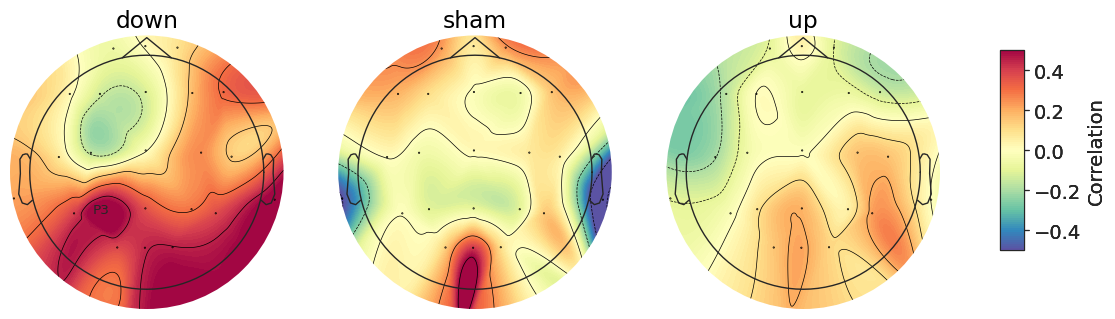

In [81]:
for stage in ['NREM2','NREM3','REM']: #grouped_data.Stage.unique():
    # extract data for each correlation (slope & intercept)
    for corr in ['Corr_Slope_RMSE']:#, 'Corr_Intercept_RMSE']:
        # initialize figure
        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        # extract data for each stage and condition
        for cond, ax in zip(grouped_data.Condition.unique(), axes):
            # extract data for each stage and condition
            color_data = grouped_data.groupby(['Stage','Condition','Chan'])[[corr, 'P_Value_Slope_RMSE']].mean()#.loc[stage]
            data_ = grouped_data.groupby(['Stage','Condition','Chan'])[[corr, 'P_Value_Slope_RMSE']].mean().loc[stage].loc[cond]
            vlim =(np.percentile(color_data, 1), np.percentile(color_data, 99))
            topoplot(data=data_[corr], 
                     vmin=-.5, vmax=.5,
                     #vmin=vlim[0], vmax=vlim[1], 
                     mask=data_['P_Value_Slope_RMSE'] < .05,
                     montage="standard_1005", #cmap='viridis', 
                     title=f'{stage} {cond}', figsize=(4, 4), cbar_title=f'{corr.split("_")[1]} Correlation', axes=ax,
                     #**dict(names=None), # type: ignore
                     )

        # save figure    
        plt.savefig(f'/media/administrator/data/Study_1_data/Figures/Aperiodic/{stage}_{cond}_{corr.split("_")[1]}_corr.png')                     

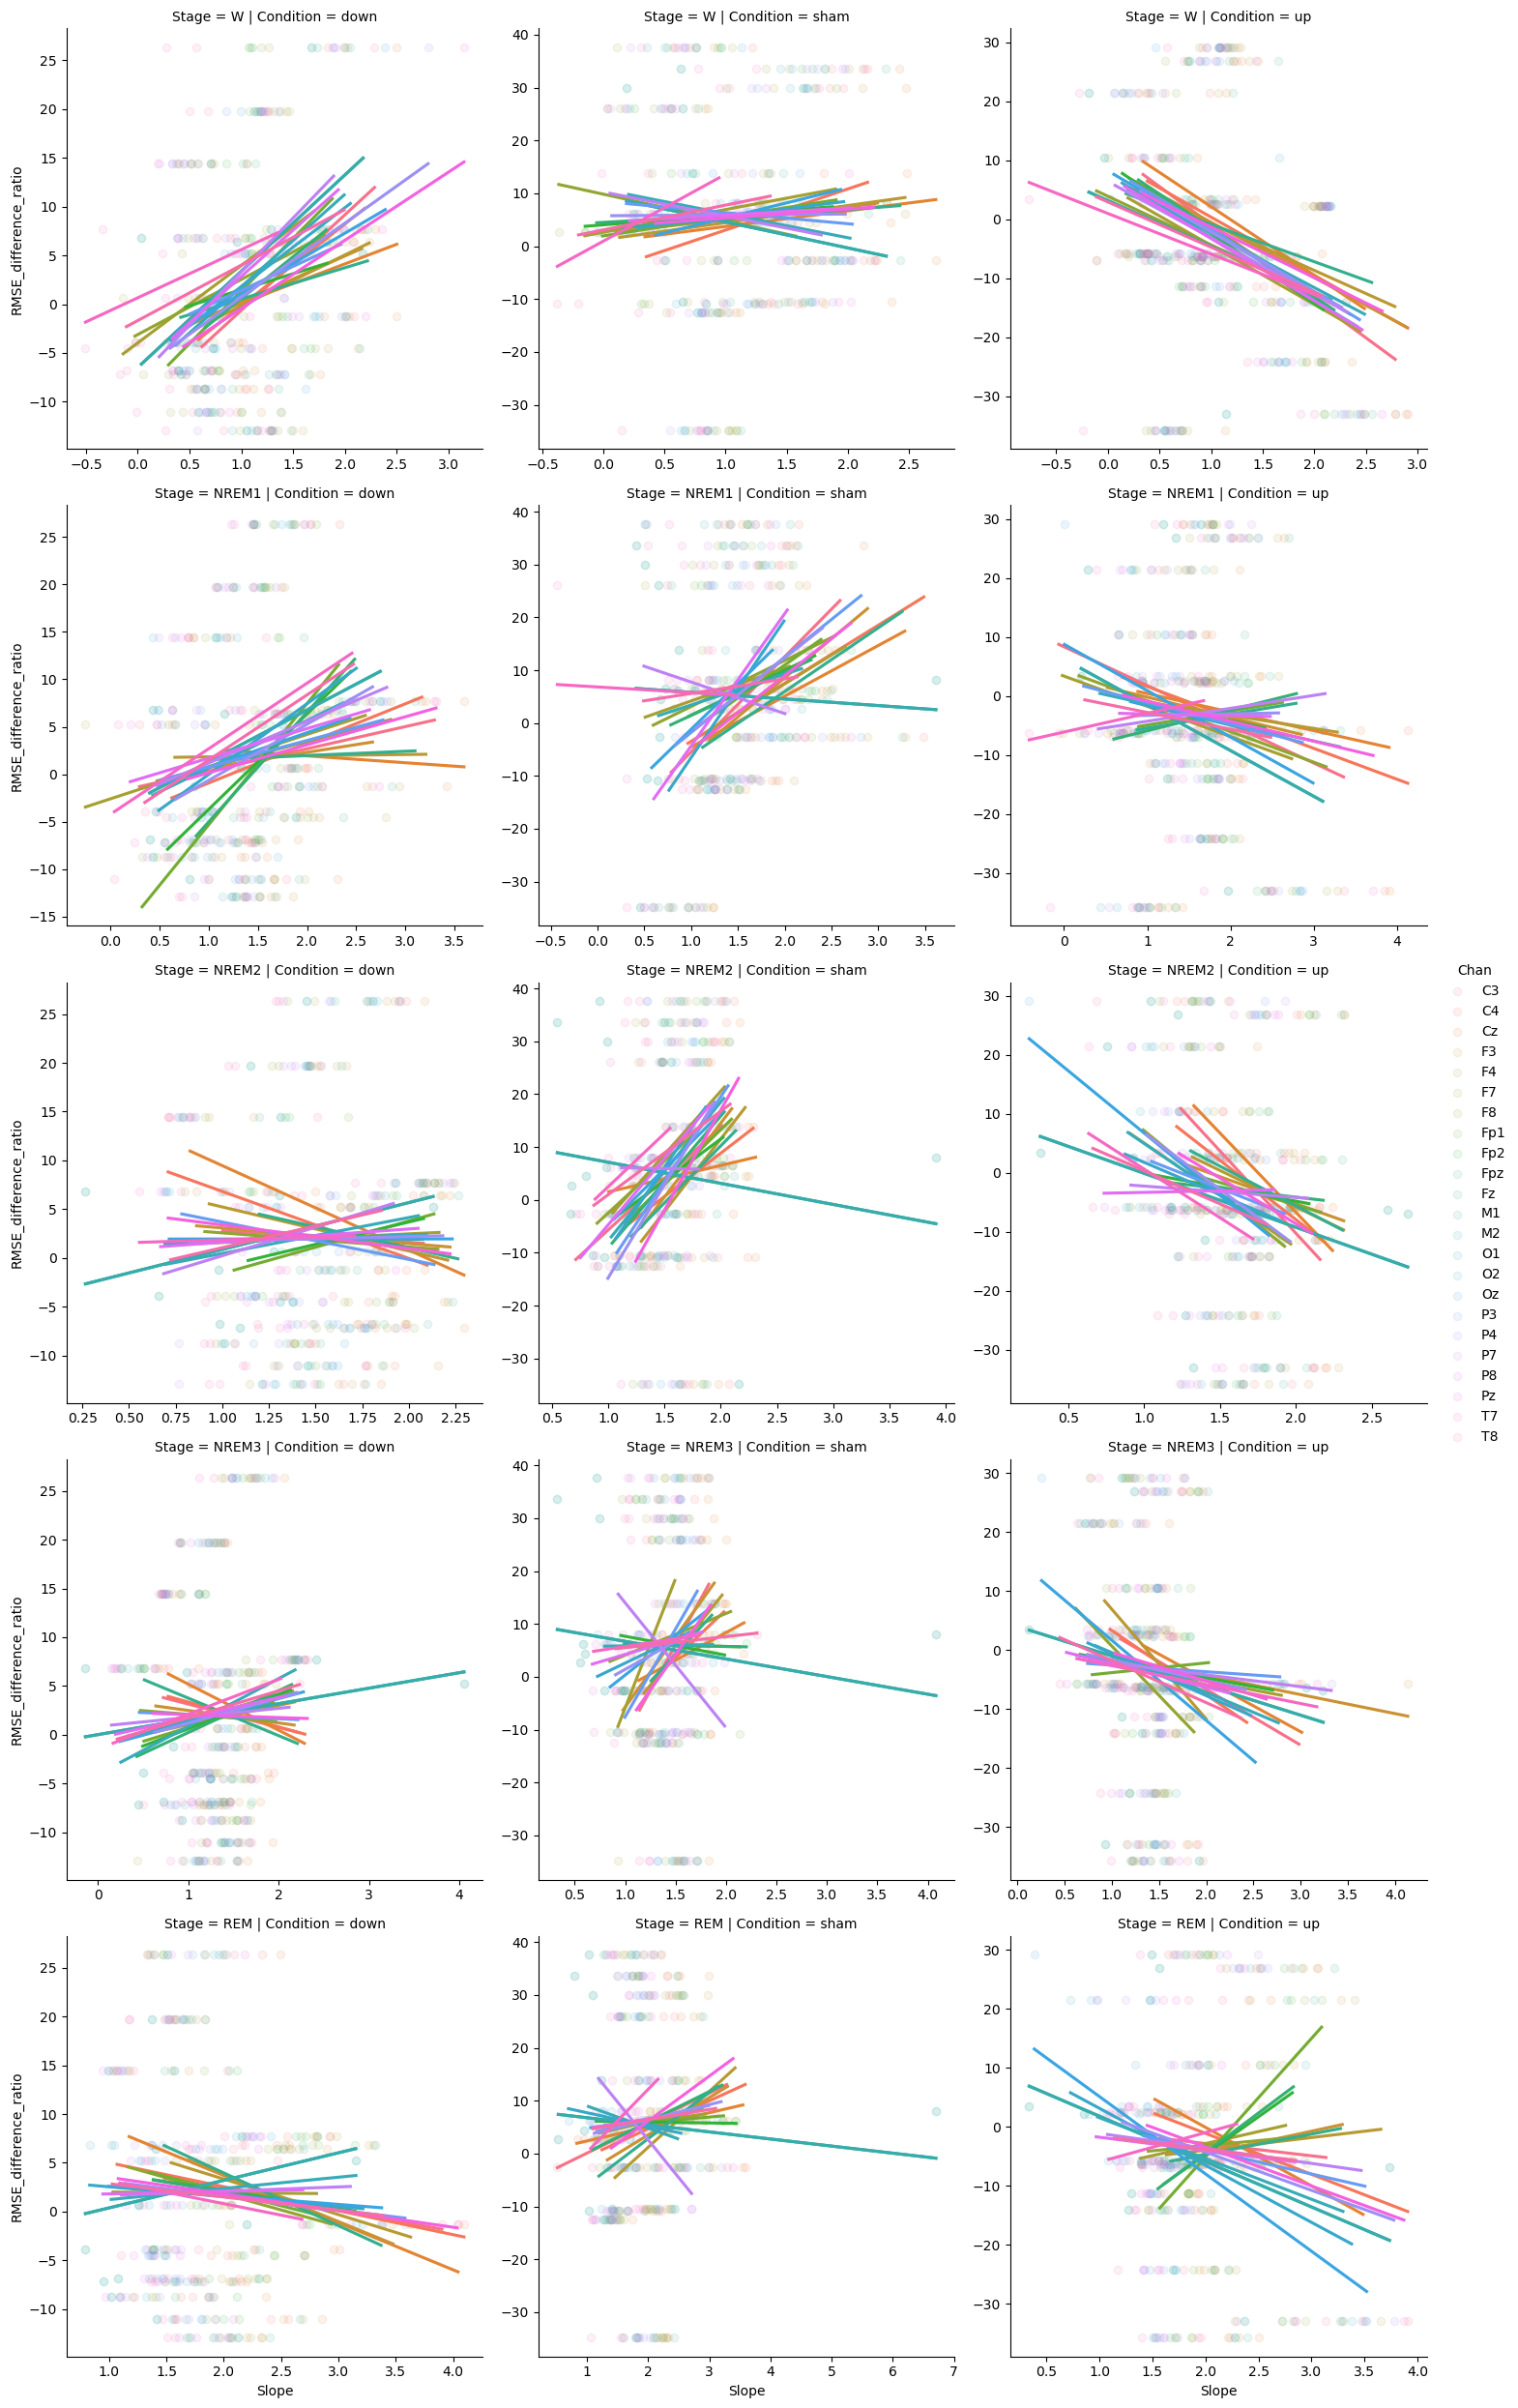

In [93]:
sns.lmplot(merged_avg, x='Slope', y='RMSE_difference_ratio', col='Condition', hue='Chan', row='Stage',
           facet_kws=dict(sharex=False, sharey=False), ci=None, scatter_kws={'alpha':0.1}) # type: ignore

In [ ]:
# LMER for contrast ~ Slope + Stage + Condition + (1|subject)
lmer = smf.mixedlm("RMSE_difference_ratio ~ Slope + Stage + Condition", merged_avg, groups=merged_avg["Subject"])
lmer_fit = lmer.fit()
print(lmer_fit.summary())
full_ll = lmer_fit.llf # log-likelihood of full model

In [ ]:
# LMER for contrast ~ Slope + Condition + (1|subject)
log_likelihoods = []
for stage in ['NREM2', 'NREM3', 'REM']:#merged_avg.Stage.unique():
    stage_df = merged_avg[merged_avg.Stage == stage]
    md = smf.mixedlm("RMSE_difference_ratio ~ Slope+Condition", stage_df, groups=stage_df["Subject"])
    mdf = md.fit()
    print(stage, mdf.summary())
    log_likelihoods.append(mdf.llf)

In [ ]:
#calculate likelihood ratio Chi-Squared test statistic
LR_statistic = -2*(log_likelihoods-full_ll)

print(LR_statistic)

#calculate p-value of test statistic using 2 degrees of freedom
p_val = stats.chi2.sf(LR_statistic, len(log_likelihoods))
p_val

In [ ]:
# Likelhood ratio test to compare sleep stage slopes as predictors of contrast
md = smf.mixedlm("RMSE_difference_ratio ~ Slope*Condition", merged_avg[merged_avg.Stage=='REM'], 
                 groups=merged_avg[merged_avg.Stage=='REM']["Subject"])
mdf = md.fit()
print(mdf.summary())

In [ ]:
md = smf.mixedlm("RMSE_difference_ratio ~ Slope*Condition", merged_avg[merged_avg.Stage=='N3'], 
                 groups=merged_avg[merged_avg.Stage=='N3']["Subject"])
mdf = md.fit()
print(mdf.summary())

In [ ]:
pg.rm_anova(data=merged_avg, dv='Slope', within=['Condition','Stage'],
            subject='Subject', detailed=True)

In [ ]:
# Compute correlations between Slope and contrast for each Stage
correlations = merged_avg.groupby('Stage').apply(lambda group: group['Slope'].corr(group['RMSE_difference_ratio'])).reset_index()
correlations.columns = ['Stage', 'Correlation']

correlations

In [ ]:
sns.barplot(data=merged_avg, x='Stage', y='Slope', hue='Condition')

In [ ]:
psds[0][(3.0, 'C3', 'sham', '0RCB4IRJ')].plot(plt_log=True)

In [ ]:
C3_Wake = [psds[idx](0.0, 'C3', 'sham', sub) for idx, sub in enumerate(good_subs)]